In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import textwrap

# **30 MENIT**

## **100% Watercut**

In [2]:
# Baca Well Identity
df_wellidentity = pd.read_csv("Well Identity.csv")

# Ambil nama sheet dari Well Identity (baris pertama)
sheet_name = df_wellidentity.loc[0, "Well Identity"]

# Baca Excel sesuai sheet_name yang diambil dari Well Identity
df_wc = pd.read_excel("D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Zona 11\Kajian Analisis Data LPO dan Digitalisasi\ZONA 11 (ESP)\ESP History SKW\Production SKW.xlsx", sheet_name=str(sheet_name))

<>:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\azhar\AppData\Local\Temp\ipykernel_19184\4183493421.py:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  df_wc = pd.read_excel("D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Zona 11\Kajian Analisis Data LPO dan Digitalisasi\ZONA 11 (ESP)\ESP History SKW\Production SKW.xlsx", sheet_name=str(sheet_name))


In [3]:
# --- Hapus baris index 0-5 dan reset index ---
df_wc = df_wc.iloc[6:].reset_index(drop=True)

In [4]:
# Ambil hanya kolom sampai 'Unnamed: 11' saja
df_wc = df_wc.iloc[:, :12]   # ambil 12 kolom pertama (0 sampai 11)

In [5]:
df_wc

,SUKOWATI - 30,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2025-06-26 00:00:00,160,S/I,0,0,0,0,0,-,-,852356.434089,852.356434
1,2025-06-27 00:00:00,160,S/I,24,179.593887,2107.941818,2287.535705,384.005266,92.149024,2138.18673,852536.027976,852.536028
2,2025-06-28 00:00:00,160,S/I,24,215.72762,2043.52,2259.24762,420.458632,90.451351,1949.025498,852751.755596,852.751756
3,2025-06-29 00:00:00,160,S/I,24,212.065873,2037.634286,2249.700158,444.299152,90.573594,2095.099729,852963.821469,852.963821
4,2025-06-30 00:00:00,160,S/I,24,212.908569,2036.79159,2249.700158,444.299152,90.536136,2086.807285,853176.730037,853.17673
5,2025-07-01 00:00:00,160,S/I,24,212.27725,2037.422908,2249.700158,444.299152,90.564198,2093.013509,853389.007287,853.389007
6,2025-07-02 00:00:00,160,S/I,24,178.679344,2102.965714,2281.645058,388.872781,92.168837,2176.372336,853567.686632,853.567687
7,2025-07-03 00:00:00,160,S/I,24,179.19138,2102.453679,2281.645058,388.872781,92.146395,2170.153398,853746.878011,853.746878
8,2025-07-04 00:00:00,160,S/I,24,179.137026,2102.508032,2281.645058,388.872781,92.148778,2170.811865,853926.015037,853.926015
9,2025-07-05 00:00:00,160,S/I,24,170.465915,2259.054857,2429.520772,380.219025,92.983558,2230.469514,854096.480952,854.096481


In [6]:
# --- Ubah nama kolom sesuai permintaan ---
df_wc.columns = [
    "Date", "FWHP", "CHOKE", "TIME PROD", "OIL", "WATER", 
    "GROSS", "GAS", "WC", "GOR", "CUMM OIL", "CUMM OIL (2)"
]

In [7]:
df_wc

,Date,FWHP,CHOKE,TIME PROD,OIL,WATER,GROSS,GAS,WC,GOR,CUMM OIL,CUMM OIL (2)
0,2025-06-26 00:00:00,160,S/I,0,0,0,0,0,-,-,852356.434089,852.356434
1,2025-06-27 00:00:00,160,S/I,24,179.593887,2107.941818,2287.535705,384.005266,92.149024,2138.18673,852536.027976,852.536028
2,2025-06-28 00:00:00,160,S/I,24,215.72762,2043.52,2259.24762,420.458632,90.451351,1949.025498,852751.755596,852.751756
3,2025-06-29 00:00:00,160,S/I,24,212.065873,2037.634286,2249.700158,444.299152,90.573594,2095.099729,852963.821469,852.963821
4,2025-06-30 00:00:00,160,S/I,24,212.908569,2036.79159,2249.700158,444.299152,90.536136,2086.807285,853176.730037,853.17673
5,2025-07-01 00:00:00,160,S/I,24,212.27725,2037.422908,2249.700158,444.299152,90.564198,2093.013509,853389.007287,853.389007
6,2025-07-02 00:00:00,160,S/I,24,178.679344,2102.965714,2281.645058,388.872781,92.168837,2176.372336,853567.686632,853.567687
7,2025-07-03 00:00:00,160,S/I,24,179.19138,2102.453679,2281.645058,388.872781,92.146395,2170.153398,853746.878011,853.746878
8,2025-07-04 00:00:00,160,S/I,24,179.137026,2102.508032,2281.645058,388.872781,92.148778,2170.811865,853926.015037,853.926015
9,2025-07-05 00:00:00,160,S/I,24,170.465915,2259.054857,2429.520772,380.219025,92.983558,2230.469514,854096.480952,854.096481


## **Fail Pred**

In [8]:
df_ori = pd.read_csv('SKW_final_w_Pd.csv', parse_dates=['Reading Time'])

In [9]:
df11 = pd.read_csv('X_predict_30menit.csv')

In [10]:
df_all = pd.read_csv('df_all.csv')

In [11]:
slopes_df = pd.read_csv('slopes_df_30menit.csv')

In [12]:
from joblib import load

KNN = load(r'D:\Garpit\Kerja\Kerja Beneran\Zona 11 DB LPO\Garpit Area\Last Okt 2025\Failure Prediction\knn_tanpa SMOTE_model.pkl')

c:\Users\azhar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
df_all.head()

,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,2025-06-26 11:30:00,4.3,60.0,0.00,0.0,32.0,32.0,0.000000,239.130435
1,2025-06-26 12:00:00,0.0,0.0,0.00,0.0,32.0,32.0,0.000000,0.000000
2,2025-06-26 12:30:00,0.0,0.0,0.00,0.0,32.0,32.0,0.000000,0.000000
3,2025-06-26 13:00:00,0.0,0.0,0.00,0.0,32.0,32.0,0.000000,0.000000
4,2025-06-26 13:30:00,0.0,0.0,1246.65,1247.8,182.4,176.8,0.063222,0.000000


In [14]:
slopes_df.head()

,Window_Start_Time,A,IP,DP,IT,MT,V,R
0,2025-06-26 12:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
1,2025-06-26 12:30:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
2,2025-06-26 13:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
3,2025-06-26 13:30:00,0.000000,-0.000167,0.00000,0.000333,0.000333,0.0,0.000000
4,2025-06-26 14:00:00,-0.001018,-0.003229,-0.20225,0.000164,-0.000514,0.0,-0.524042


In [15]:
df11.head()

,A,IP,DP,IT,MT,V,R
0,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
1,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
2,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
3,0.000000,-0.000167,0.00000,0.000333,0.000333,0.0,0.000000
4,-0.001018,-0.003229,-0.20225,0.000164,-0.000514,0.0,-0.524042


In [16]:
predictions = KNN.predict(df11)

In [17]:
def status(x):
    x = int(x)
    if(x==0):
        return "Running"
    elif(x==1):
        return "Low PI"
    elif(x==2):
        return "Pump Wear"
    elif(x==3):
        return "Tubing Leak"
    elif(x==4):
        return "Higher PI"
    elif(x==5):
        return "Increase in Frequency"
    elif(x==6):
        return "Open Choke"
    elif(x==7):
        return "Increase in Watercut"
    elif(x==8):
        return "Sand Ingestion"
    elif(x==9):
        return "Closed Valve"
    elif(x==10):
        return "Low PI 2"
    else:
        return "Unidentified"

def recommendation(x):
    x = int(x)
    if(x==0):
        return " "
    elif(x==1):
        print ("The Possibility Causes: \n 1. Well productivity less than pump design range \n 2. Restricted pump")
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Analyze the fluid level and Bottom Hole Pressure (BHP) data! \n   If in acceptable range, Adjust the tubing well head pressure and bring the pump production rate within design rate', end = '\n')
        print ('2. Check the possibility of restricted pump! \n   Pumping fluids through tubing when water sources are available.')
    elif(x==2):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Verify if vibration have increased by 20% from the pump install date', end = '\n')
        print ('2. Do shut-in test while the surface check valve is closed, and the pump is running')
    elif(x==3):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Confirm by a pressure test at the tubing wellhead', end = '\n')
        print ('2. Meanwhile, fill up the tubing and pressure up against RCV')
    elif(x==4):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Adjust the tubing well head pressure and bring the pump production rate within design rate', end = '\n')
        print ('2. Conduct the fluid analysis as a basis for re-design pump')
    elif(x==5):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Lower the value of frequency using VSD.', end = '\n')
        print ('2. Check the pump discharge pressure and compare to previous well data history')
    elif(x==6):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('Analyze the fluid level and Bottom Hole Pressure (BHP) data!')
    elif(x==7):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Analyze the fluid level and Bottom Hole Pressure (BHP) data!', end = '\n')
        print ('2. Adjust the tubing well head pressure and bring the pump production rate within design rate')
    elif(x==8):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Check flow line and separator for evidence of sand, mud, or debris.', end = '\n')
        print ('2. Design solid control system for next installation')
    elif(x==9):
        print ('NOTIFICATIONS FOR ENGINEER!')
        print ('1. Verify if the valve was deliberately partially closed by Field Service Tech', end = '\n')
        print ('2. Contact the Field Service Tech to check out well on location')
    else:
        return "Unidentified"

In [18]:
# Create a DataFrame with window start times and predictions
prediction_results_df = pd.DataFrame({
    'Window_Start_Time': slopes_df['Window_Start_Time'],
    'Prediction': predictions
})

# Apply the status and recommendation functions
prediction_results_df['Status'] = prediction_results_df['Prediction'].apply(status)
prediction_results_df['Recommendation'] = prediction_results_df['Prediction'].apply(recommendation)


# Display the results
display(prediction_results_df.head())

,Window_Start_Time,Prediction,Status,Recommendation
0,2025-06-26 12:00:00,0,Running,
1,2025-06-26 12:30:00,0,Running,
2,2025-06-26 13:00:00,0,Running,
3,2025-06-26 13:30:00,0,Running,
4,2025-06-26 14:00:00,0,Running,


In [19]:
# # Loop cek kondisi dengan toleransi
# for idx, row in prediction_results_df.iterrows():
#     # Cek di df_all
#     match_row = df_all[df_all["Reading Time"] == row["Window_Start_Time"]]
#     # Cek di slopes_df
#     slope_row = slopes_df[slopes_df["Window_Start_Time"] == row["Window_Start_Time"]]

#     if not match_row.empty and not slope_row.empty:
#         amps = match_row["Average Amps (A) (Raw)"].iloc[0]
#         freq = match_row["Drive Frequency (Hz) (Raw)"].iloc[0]
#         rate = match_row["Virtual Rate (BFPD) (Raw)"].iloc[0]

#         dp = slope_row["DP"].iloc[0]
#         it = slope_row["IT"].iloc[0]
#         mt = slope_row["MT"].iloc[0]
#         v  = slope_row["V"].iloc[0]
#         r  = slope_row["R"].iloc[0]

#         # Gunakan np.isclose untuk toleransi nilai nyaris nol
#         if (np.isclose(amps, 0, atol=1e-10) and
#             np.isclose(freq, 0, atol=1e-10) and
#             np.isclose(rate, 0, atol=1e-10) and
#             np.isclose(dp, 0, atol=1e-10) and
#             np.isclose(it, 0, atol=1e-10) and
#             np.isclose(mt, 0, atol=1e-10) and
#             np.isclose(v, 0, atol=1e-10) and
#             np.isclose(r, 0, atol=1e-10)):
            
#             prediction_results_df.at[idx, "Prediction"] = 10
#             prediction_results_df.at[idx, "Status"] = "Electrical Downhole Problem"

In [20]:
# # Loop cek kondisi
# for idx, row in prediction_results_df.iterrows():
#     match_row = df_all[df_all["Reading Time"] == row["Window_Start_Time"]]
#     if not match_row.empty:
#         amps = match_row["Average Amps (A) (Raw)"].iloc[0]
#         freq = match_row["Drive Frequency (Hz) (Raw)"].iloc[0]
#         rate = match_row["Virtual Rate (BFPD) (Raw)"].iloc[0]

#         if amps == 0 and freq == 0 and rate == 0:
#             prediction_results_df.at[idx, "Prediction"] = 10
#             prediction_results_df.at[idx, "Status"] = "Electrical Downhole Problem"

In [21]:
# # --- Pastikan kolom waktu bertipe datetime ---
# prediction_results_df["Window_Start_Time"] = pd.to_datetime(prediction_results_df["Window_Start_Time"])
# df_ori["Reading Time"] = pd.to_datetime(df_ori["Reading Time"])
# df_all["Reading Time"] = pd.to_datetime(df_all["Reading Time"])
# slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# # Kolom yang dicek untuk variasi di df_ori
# cols_check = [
#     "Intake Pressure (psi) (Raw)",
#     "Discharge Pressure (psi) (Raw)",
#     "Intake Temperature (F) (Raw)",
#     "Motor Temperature (F) (Raw)",
#     "Vibration (gravit) (Raw)",
#     "Virtual Rate (BFPD) (Raw)"
# ]

# # Loop prediksi
# for idx, row in prediction_results_df.iterrows():
#     # Cek di df_all
#     match_row = df_all[df_all["Reading Time"] == row["Window_Start_Time"]]
#     # Cek di slopes_df
#     slope_row = slopes_df[slopes_df["Window_Start_Time"] == row["Window_Start_Time"]]

#     if not match_row.empty and not slope_row.empty:
#         # Data dari df_all
#         amps = match_row["Average Amps (A) (Raw)"].iloc[0]
#         freq = match_row["Drive Frequency (Hz) (Raw)"].iloc[0]
#         rate = match_row["Virtual Rate (BFPD) (Raw)"].iloc[0]

#         # Data dari slopes_df
#         dp = slope_row["DP"].iloc[0]
#         it = slope_row["IT"].iloc[0]
#         mt = slope_row["MT"].iloc[0]
#         v  = slope_row["V"].iloc[0]
#         r  = slope_row["R"].iloc[0]

#         # --- aturan tambahan: cek variasi df_ori dalam window 30 menit ---
#         start_time = row["Window_Start_Time"]
#         end_time = start_time + pd.Timedelta(minutes=30)

#         subset_ori = df_ori[(df_ori["Reading Time"] >= start_time) &
#                             (df_ori["Reading Time"] < end_time)]

#         has_variation = False
#         if not subset_ori.empty:
#             for c in cols_check:
#                 if subset_ori[c].nunique() > 1:  # ada variasi nilai
#                     has_variation = True
#                     break

#         # --- aturan lama + aturan baru ---
#         if (np.isclose(amps, 0, atol=1e-10) and
#             np.isclose(freq, 0, atol=1e-10) and
#             np.isclose(rate, 0, atol=1e-10) and
#             np.isclose(dp, 0, atol=1e-10) and
#             np.isclose(it, 0, atol=1e-10) and
#             np.isclose(mt, 0, atol=1e-10) and
#             np.isclose(v, 0, atol=1e-10) and
#             np.isclose(r, 0, atol=1e-10) and
#             not has_variation):   # hanya jika tidak ada variasi
#             prediction_results_df.at[idx, "Prediction"] = 10
#             prediction_results_df.at[idx, "Status"] = "Electrical Downhole Problem"

In [22]:
# # --- Pastikan kolom waktu bertipe datetime ---
# prediction_results_df["Window_Start_Time"] = pd.to_datetime(prediction_results_df["Window_Start_Time"])
# df_ori["Reading Time"] = pd.to_datetime(df_ori["Reading Time"])
# df_all["Reading Time"] = pd.to_datetime(df_all["Reading Time"])
# slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# # --- tolerance untuk cek nol (numeric noise handling) ---
# TOL = 1e-08   # bisa disesuaikan (contoh: 1e-07 jika masih ada noise lebih besar)

# # Kolom yang dicek untuk variasi di df_ori
# cols_check = [
#     "Intake Pressure (psi) (Raw)",
#     "Discharge Pressure (psi) (Raw)",
#     "Intake Temperature (F) (Raw)",
#     "Motor Temperature (F) (Raw)",
#     "Vibration (gravit) (Raw)",
#     "Virtual Rate (BFPD) (Raw)"
# ]

# # Loop prediksi
# for idx, row in prediction_results_df.iterrows():
#     # Cek di df_all
#     match_row = df_all[df_all["Reading Time"] == row["Window_Start_Time"]]
#     # Cek di slopes_df
#     slope_row = slopes_df[slopes_df["Window_Start_Time"] == row["Window_Start_Time"]]

#     if not match_row.empty and not slope_row.empty:
#         # Data dari df_all
#         amps = match_row["Average Amps (A) (Raw)"].iloc[0]
#         freq = match_row["Drive Frequency (Hz) (Raw)"].iloc[0]
#         rate = match_row["Virtual Rate (BFPD) (Raw)"].iloc[0]

#         # Data dari slopes_df
#         dp = slope_row["DP"].iloc[0]
#         it = slope_row["IT"].iloc[0]
#         mt = slope_row["MT"].iloc[0]
#         v  = slope_row["V"].iloc[0]
#         r  = slope_row["R"].iloc[0]

#         # --- cek window 30 menit di df_ori ---
#         start_time = row["Window_Start_Time"]
#         end_time = start_time + pd.Timedelta(minutes=30)

#         subset_ori = df_ori[(df_ori["Reading Time"] >= start_time) &
#                             (df_ori["Reading Time"] < end_time)]

#         has_variation = False
#         if not subset_ori.empty:
#             for c in cols_check:
#                 if subset_ori[c].nunique() > 1:  # ada variasi nilai
#                     has_variation = True
#                     break

#         # --- aturan baru: Shut-in ---
#         if np.isclose(amps, 0, atol=TOL) and np.isclose(freq, 0, atol=TOL):
#             other_cols = [
#                 "Virtual Rate (BFPD) (Raw)",
#                 "Discharge Pressure (psi) (Raw)",
#                 "Intake Temperature (F) (Raw)",
#                 "Motor Temperature (F) (Raw)",
#                 "Vibration (gravit) (Raw)"
#             ]
#             all_zero = all(np.isclose(match_row[c].iloc[0], 0, atol=TOL) for c in other_cols)

#             if all_zero:
#                 prediction_results_df.at[idx, "Prediction"] = 11
#                 prediction_results_df.at[idx, "Status"] = "Shut-in"
#                 continue  # langsung ke row berikutnya

#             if has_variation:
#                 prediction_results_df.at[idx, "Prediction"] = 11
#                 prediction_results_df.at[idx, "Status"] = "Shut-in"
#                 continue  # langsung ke row berikutnya

#         # --- aturan lama: EDP ---
#         if (np.isclose(amps, 0, atol=TOL) and
#             np.isclose(freq, 0, atol=TOL) and
#             np.isclose(rate, 0, atol=TOL) and
#             np.isclose(dp, 0, atol=TOL) and
#             np.isclose(it, 0, atol=TOL) and
#             np.isclose(mt, 0, atol=TOL) and
#             np.isclose(v, 0, atol=TOL) and
#             np.isclose(r, 0, atol=TOL) and
#             not has_variation):
#             prediction_results_df.at[idx, "Prediction"] = 10
#             prediction_results_df.at[idx, "Status"] = "Electrical Downhole Problem"

In [23]:
# ===========================================
# 1. --- Konversi tipe data ---
# ===========================================
prediction_results_df["Window_Start_Time"] = pd.to_datetime(prediction_results_df["Window_Start_Time"])
df_ori["Reading Time"] = pd.to_datetime(df_ori["Reading Time"])
df_all["Reading Time"] = pd.to_datetime(df_all["Reading Time"])
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])
df_wc["Date"] = pd.to_datetime(df_wc["Date"])

# Pastikan kolom WC numerik
df_wc["WC"] = pd.to_numeric(df_wc["WC"], errors="coerce")

TOL = 1e-8

# ===========================================
# 2. --- Preprocess: variasi nilai per 30 menit ---
# ===========================================
cols_check = [
    "Intake Pressure (psi) (Raw)",
    "Discharge Pressure (psi) (Raw)",
    "Intake Temperature (F) (Raw)",
    "Motor Temperature (F) (Raw)",
    "Vibration (gravit) (Raw)",
    "Virtual Rate (BFPD) (Raw)"
]

# Floor timestamp agar window 30 menit selaras
df_ori["Window_Start_Time"] = df_ori["Reading Time"].dt.floor("30min")

# Hitung apakah ada variasi di setiap window
variation = (
    df_ori.groupby("Window_Start_Time")[cols_check]
    .nunique()
    .gt(1)     # True jika ada >1 nilai unik
    .any(axis=1)
    .reset_index(name="has_variation")
)

# ===========================================
# 3. --- Merge semua sumber data jadi satu ---
# ===========================================
merged = (
    prediction_results_df
    .merge(df_all, left_on="Window_Start_Time", right_on="Reading Time", how="left")
    .merge(slopes_df, on="Window_Start_Time", how="left", suffixes=("", "_slope"))
    .merge(df_wc, left_on=prediction_results_df["Window_Start_Time"].dt.normalize(),
           right_on="Date", how="left")
    .merge(variation, on="Window_Start_Time", how="left")
)

# ===========================================
# 4. --- Siapkan kolom output ---
# ===========================================
merged["Prediction"] = merged.get("Prediction", np.nan)
merged["Status"] = merged.get("Status", np.nan)

# ===========================================
# 5. --- Aturan 100% Watercut ---
# ===========================================
mask_wc100 = np.isclose(merged["WC"], 100, atol=1e-6)
merged.loc[mask_wc100, ["Prediction", "Status"]] = [12, "100% Watercut"]

# ===========================================
# 6. --- Aturan Shut-in ---
# ===========================================
amps = merged["Average Amps (A) (Raw)"]
freq = merged["Drive Frequency (Hz) (Raw)"]
rate = merged["Virtual Rate (BFPD) (Raw)"]
dp   = merged["DP"]
it   = merged["IT"]
mt   = merged["MT"]
v    = merged["V"]
r    = merged["R"]
has_var = merged["has_variation"].fillna(False)

mask_shutin = (
    np.isclose(amps, 0, atol=TOL) &
    np.isclose(freq, 0, atol=TOL) &
    (
        has_var |
        (
            np.isclose(merged["Virtual Rate (BFPD) (Raw)"], 0, atol=TOL) &
            np.isclose(merged["Discharge Pressure (psi) (Raw)"], 0, atol=TOL) &
            np.isclose(merged["Vibration (gravit) (Raw)"], 0, atol=TOL)
        )
    )
)

merged.loc[mask_shutin, ["Prediction", "Status"]] = [11, "Shut-in"]

# ===========================================
# 7. --- Aturan Electrical Downhole Problem (EDP) ---
# ===========================================
mask_edp = (
    np.isclose(amps, 0, atol=TOL) &
    np.isclose(freq, 0, atol=TOL) &
    np.isclose(rate, 0, atol=TOL) &
    np.isclose(dp, 0, atol=TOL) &
    np.isclose(it, 0, atol=TOL) &
    np.isclose(mt, 0, atol=TOL) &
    np.isclose(v, 0, atol=TOL) &
    np.isclose(r, 0, atol=TOL) &
    ~has_var
)

merged.loc[mask_edp, ["Prediction", "Status"]] = [10, "Electrical Downhole Problem"]

# ===========================================
# 8. --- Kembalikan hasil ke prediction_results_df ---
# ===========================================
prediction_results_df = prediction_results_df.merge(
    merged[["Window_Start_Time", "Prediction", "Status"]],
    on="Window_Start_Time",
    how="left",
    suffixes=("", "_new")
)

# Ganti kolom hasil prediksi jika kosong
prediction_results_df["Prediction"] = prediction_results_df["Prediction_new"].combine_first(prediction_results_df["Prediction"])
prediction_results_df["Status"] = prediction_results_df["Status_new"].combine_first(prediction_results_df["Status"])

# Hapus kolom tambahan
prediction_results_df.drop(columns=["Prediction_new", "Status_new"], inplace=True)

# ===========================================
# 9. --- Done ---
# ===========================================
print("✅ Vectorized prediction complete.")

✅ Vectorized prediction complete.


In [24]:
# --- Setelah loop utama, cek gap rules ---
prediction_results_df = prediction_results_df.sort_values("Window_Start_Time").reset_index(drop=True)
prediction_results_df["Status"] = prediction_results_df["Status"].str.strip()

for i in range(1, len(prediction_results_df)):
    prev_time = prediction_results_df.loc[i-1, "Window_Start_Time"]
    curr_time = prediction_results_df.loc[i, "Window_Start_Time"]
    gap_hours = (curr_time - prev_time).total_seconds() / 3600.0

    if gap_hours > 3:  # gap terdeteksi
        # bacaan pertama setelah gap
        first_after_gap_idx = i
        first_after_gap_time = curr_time

        # cari Shut-in dalam 3 hari setelah first_after_gap_time
        three_days_later = first_after_gap_time + pd.Timedelta(days=3)
        shutin_indices = prediction_results_df[
            (prediction_results_df["Window_Start_Time"] >= first_after_gap_time) &
            (prediction_results_df["Window_Start_Time"] <= three_days_later) &
            (prediction_results_df["Status"] == "Shut-in")
        ].index

        if len(shutin_indices) > 0:
            # ambil Shut-in terjauh
            last_shutin_idx = shutin_indices[-1]
            # semua selain Shut-in antara first_after_gap_idx sampai last_shutin_idx → Start-up Phase
            for j in range(first_after_gap_idx, last_shutin_idx):
                if prediction_results_df.loc[j, "Status"] != "Shut-in":
                    prediction_results_df.at[j, "Prediction"] = 13
                    prediction_results_df.at[j, "Status"] = "Start-up Phase"
        else:
            # tidak ada Shut-in, ubah EDP 24 jam ke depan menjadi Start-up Phase
            end_24h = first_after_gap_time + pd.Timedelta(hours=24)
            edp_indices = prediction_results_df[
                (prediction_results_df["Window_Start_Time"] >= first_after_gap_time) &
                (prediction_results_df["Window_Start_Time"] <= end_24h) &
                (prediction_results_df["Status"].str.contains("Electrical Downhole Problem"))
            ].index
            for j in edp_indices:
                prediction_results_df.at[j, "Prediction"] = 13
                prediction_results_df.at[j, "Status"] = "Start-up Phase"

In [25]:
# from collections import Counter
# import pandas as pd

# # Pastikan kolom waktu dalam format datetime
# prediction_results_df['Window_Start_Time'] = pd.to_datetime(prediction_results_df['Window_Start_Time'])
# prediction_results_df = prediction_results_df.sort_values('Window_Start_Time')
# prediction_results_df = prediction_results_df.set_index('Window_Start_Time')

# # Tambahkan kolom tanggal untuk grouping harian
# prediction_results_df['Date'] = prediction_results_df.index.date

# # Buat dictionary frekuensi masalah non-Running per hari
# daily_problem_counts_dict = {}
# for date, group in prediction_results_df.groupby('Date'):
#     non_running = group[group['Status'] != 'Running']
#     daily_problem_counts_dict[date] = Counter(non_running['Status'])

# # Resample per 3 jam
# grouped = prediction_results_df.resample('3H')

# results = []
# for timestamp, group in grouped:
#     total = len(group)
#     if total == 0:
#         continue

#     running_count = (group['Status'] == 'Running').sum()
#     non_running_count = total - running_count
#     window_date = group.index[0].date()
#     day_problem_counter = daily_problem_counts_dict.get(window_date, {})

#     if non_running_count >= (total/2):
#         # Hitung status dominan tanpa Running
#         status_counts = group['Status'].value_counts()
#         status_counts_no_running = status_counts.drop('Running', errors='ignore')
#         top_count = status_counts_no_running.max()
#         top_statuses = status_counts_no_running[status_counts_no_running == top_count]

#         if len(top_statuses) == 1:
#             dominant = top_statuses.idxmax()
#         else:
#             # Tie-breaker berdasarkan frekuensi harian
#             tie_candidates = list(top_statuses.index)
#             tie_day_counts = {status: day_problem_counter.get(status, 0) for status in tie_candidates}
#             dominant = max(tie_day_counts, key=tie_day_counts.get)
#     else:
#         dominant = 'Running'

#     results.append({
#         'Window_Start_Time': timestamp,
#         'Dominant Status': dominant
#     })

# # Hasil akhir
# result_df = pd.DataFrame(results)

In [26]:
from collections import Counter
import pandas as pd

# Pastikan kolom waktu dalam format datetime
prediction_results_df['Window_Start_Time'] = pd.to_datetime(prediction_results_df['Window_Start_Time'])
prediction_results_df = prediction_results_df.sort_values('Window_Start_Time')
prediction_results_df = prediction_results_df.set_index('Window_Start_Time')

# Tambahkan kolom tanggal untuk grouping harian
prediction_results_df['Date'] = prediction_results_df.index.date

# Buat dictionary frekuensi masalah non-Running per hari
daily_problem_counts_dict = {}
for date, group in prediction_results_df.groupby('Date'):
    non_running = group[(group['Status'] != 'Running') & (group['Status'] != 'Shut-in')]
    daily_problem_counts_dict[date] = Counter(non_running['Status'])

# Resample per 3 jam
grouped = prediction_results_df.resample('3H')

results = []
for timestamp, group in grouped:
    total = len(group)
    if total == 0:
        continue

    # Cek jumlah Shut-in
    shutin_count = (group['Status'] == 'Shut-in').sum()
    if shutin_count > total / 2:
        dominant = 'Shut-in'
    else:
        # Abaikan Shut-in dari perhitungan
        group_no_shutin = group[group['Status'] != 'Shut-in']
        total_valid = len(group_no_shutin)

        if total_valid == 0:
            continue  # kalau semua Shut-in, sudah tertangani di atas

        running_count = (group_no_shutin['Status'] == 'Running').sum()
        non_running_count = total_valid - running_count
        window_date = group.index[0].date()
        day_problem_counter = daily_problem_counts_dict.get(window_date, {})

        if non_running_count >= (total_valid / 2):
            # Hitung status dominan tanpa Running
            status_counts = group_no_shutin['Status'].value_counts()
            status_counts_no_running = status_counts.drop('Running', errors='ignore')

            top_count = status_counts_no_running.max()
            top_statuses = status_counts_no_running[status_counts_no_running == top_count]

            if len(top_statuses) == 1:
                dominant = top_statuses.idxmax()
            else:
                # Tie-breaker berdasarkan frekuensi harian
                tie_candidates = list(top_statuses.index)
                tie_day_counts = {status: day_problem_counter.get(status, 0) for status in tie_candidates}
                dominant = max(tie_day_counts, key=tie_day_counts.get)
        else:
            dominant = 'Running'

    results.append({
        'Window_Start_Time': timestamp,
        'Dominant Status': dominant
    })

# Hasil akhir
result_df = pd.DataFrame(results)

C:\Users\azhar\AppData\Local\Temp\ipykernel_19184\37745489.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grouped = prediction_results_df.resample('3H')


In [27]:
prediction_results_df = prediction_results_df.reset_index()
prediction_results_df

,Window_Start_Time,Prediction,Status,Recommendation,Date
0,2025-06-26 12:00:00,10,Electrical Downhole Problem,,2025-06-26
1,2025-06-26 12:30:00,10,Electrical Downhole Problem,,2025-06-26
2,2025-06-26 13:00:00,10,Electrical Downhole Problem,,2025-06-26
3,2025-06-26 13:30:00,11,Shut-in,,2025-06-26
4,2025-06-26 14:00:00,0,Running,,2025-06-26
...,...,...,...,...,...
1685,2025-07-31 21:30:00,0,Running,,2025-07-31
1686,2025-07-31 22:00:00,0,Running,,2025-07-31
1687,2025-07-31 22:30:00,0,Running,,2025-07-31
1688,2025-07-31 23:00:00,0,Running,,2025-07-31


In [28]:
# Hapus kolom Prediction dan Date
prediction_results_df = prediction_results_df.drop(columns=["Prediction", "Date"])

# Gabungkan berdasarkan Window_Start_Time
indicator = pd.merge(prediction_results_df, slopes_df, on="Window_Start_Time", how="outer")

# Urutkan berdasarkan waktu (opsional)
indicator = indicator.sort_values(by="Window_Start_Time").reset_index(drop=True)

In [29]:
# Fungsi untuk menentukan simbol arah
def slope_symbol(value):
    if value >= 0.005:
        return "↑"
    elif value <= 0.005:
        return "↓"
    else:
        return "→"

# Mapping kolom slope per status
status_slope_map = {
    "Low PI": ["A", "IP", "DP", "R"],
    "Pump Wear": ["A", "IP", "DP", "V", "R"],
    "Tubing Leak": ["A", "IP", "DP", "IT", "MT", "R"],
    "Higher PI": ["A", "IP", "DP", "R"],
    "Increase in Frequency": ["A", "IP", "DP", "MT", "R"],
    "Open Choke": ["A", "IP", "DP", "MT", "R"],
    "Increase in Watercut": ["A", "IP", "DP", "MT", "R"],
    "Sand Ingestion": ["A", "IP", "DP", "MT", "V", "R"],
    "Closed Valve": ["A", "IP", "DP", "IT", "MT", "R"]
}

# Fungsi pembuat kolom indicator
def make_indicator(row):
    status = row["Status"]

    # Kosong untuk status tertentu
    if status in ["Running", "Shut-in", "Start-up Phase"]:
        return ""

    # Custom text untuk status khusus
    if status == "100% Watercut":
        return "100% WC in Prod"
    elif status == "Electrical Downhole Problem":
        return "A and Freq 0, others constant"

    # Gunakan daftar kolom sesuai mapping
    cols = status_slope_map.get(status, [])
    if not cols:
        return ""  # kalau tidak ada mapping, biarkan kosong

    indicators = [f"{col}{slope_symbol(row[col])}" for col in cols]
    return " ".join(indicators)

# Tambahkan kolom Indicator
indicator["Indicator"] = indicator.apply(make_indicator, axis=1)

# Pindahkan kolom Indicator sebelum Status
cols = indicator.columns.tolist()
cols.insert(cols.index("Status"), cols.pop(cols.index("Indicator")))
indicator = indicator[cols]

# Drop kolom slope (jika tidak dibutuhkan lagi)
slope_cols = ["A", "IP", "DP", "IT", "MT", "V", "R"]
indicator = indicator.drop(columns=slope_cols)

# Reset index (opsional)
indicator = indicator.reset_index(drop=True)

In [30]:
result_3jam = result_df 

In [31]:
# dictionary rekomendasi berdasarkan Status
recommendation_by_status = {
    'Low PI': (
        "The Possibility Causes: 1. Well productivity less than pump design range 2. Restricted pump "
        "NOTIFICATIONS FOR ENGINEER! 1. Analyze the fluid level and Bottom Hole Pressure (BHP) data! "
        "If in acceptable range, Adjust the tubing well head pressure and bring the pump production rate within design rate "
        "2. Check the possibility of restricted pump! Pumping fluids through tubing when water sources are available."
    ),
    'Pump Wear': (
        "NOTIFICATIONS FOR ENGINEER! 1. Verify if vibration have increased by 20% from the pump install date "
        "2. Do shut-in test while the surface check valve is closed, and the pump is running"
    ),
    'Tubing Leak': (
        "NOTIFICATIONS FOR ENGINEER! 1. Confirm by a pressure test at the tubing wellhead "
        "2. Meanwhile, fill up the tubing and pressure up against RCV"
    ),
    'Higher PI': (
        "NOTIFICATIONS FOR ENGINEER! 1. Adjust the tubing well head pressure and bring the pump production rate within design rate "
        "2. Conduct the fluid analysis as a basis for re-design pump"
    ),
    'Increase in Frequency': (
        "NOTIFICATIONS FOR ENGINEER! 1. Lower the value of frequency using VSD. "
        "2. Check the pump discharge pressure and compare to previous well data history"
    ),
    'Open Choke': (
        "NOTIFICATIONS FOR ENGINEER! Analyze the fluid level and Bottom Hole Pressure (BHP) data!"
    ),
    'Increase in Watercut': (
        "NOTIFICATIONS FOR ENGINEER! 1. Analyze the fluid level and Bottom Hole Pressure (BHP) data! "
        "2. Adjust the tubing well head pressure and bring the pump production rate within design rate"
    ),
    'Sand Ingestion': (
        "NOTIFICATIONS FOR ENGINEER! 1. Check flow line and separator for evidence of sand, mud, or debris. "
        "2. Design solid control system for next installation"
    ),
    'Closed Valve': (
        "NOTIFICATIONS FOR ENGINEER! 1. Verify if the valve was deliberately partially closed by Field Service Tech "
        "2. Contact the Field Service Tech to check out well on location"
    ),
    'Electrical Downhole Problem': (
        "Electrical Downhole Problem suspected: 1) Verify surface equipment (VSD, step-up transformer, junction box) "
        "to confirm failure is downhole. 2) Perform a VSD soft shutdown to prevent reverse current surges. "
        "3) Conduct a DIFA (Dismantle Inspection and Failure Analysis)."
    ),
    'Shut-in': (
        "Shut-in detected. Verify operating schedule and surface conditions. Ensure Amps/Frequency are expected to be zero."
    ),
    '100% Watercut': (
        "Well producing 100% water — likely water breakthrough or reservoir depletion: "
        "Causes: 1) Water coning/channeling from aquifer, 2) Casing/tubing leak allowing water influx, "
        "3) Reservoir pressure depletion. Recommended actions: 1) Verify production test (separator test or sampling), "
        "2) Check GOR trend (near zero indicates water dominance), 3) Review well completion to find water source, "
        "4) Consider temporary shut-in or zonal isolation, 5) Evaluate re-perforation or water-shutoff treatment."
    ),
    'Start-up Phase': (
        "Start-up Phase after extended data gap: 1) Monitor equipment closely during ramp-up, "
        "2) Ensure surface controls follow the planned start-up procedure, "
        "3) Confirm downhole pressures and temperatures stabilize before normal operation."
    ),
}

# apply ke dataframe
indicator['Recommendation'] = indicator['Status'].map(recommendation_by_status).fillna(' ')



In [32]:
import re 
#  ============================================================
# 1️⃣ Pastikan kolom waktu sudah datetime
# ============================================================
indicator["Window_Start_Time"] = pd.to_datetime(indicator["Window_Start_Time"])
result_3jam["Window_Start_Time"] = pd.to_datetime(result_3jam["Window_Start_Time"])

# ============================================================
# 2️⃣ Fungsi bantu: gabungkan simbol arah per variabel
# ============================================================
def combine_indicators(indicators):
    """
    Gabungkan indikator seperti:
      'A↓ IP↓ DP↑ R↓' + 'A↓ IP↓ DP↓ R↓'
    menjadi:
      'A↓ IP↓ DP↑↓ R↓'
    """
    symbol_dict = {}

    for ind in indicators:
        if not ind or not isinstance(ind, str):
            continue
        pairs = re.findall(r"([A-Z]+)([↑↓→])", ind)
        for var, sym in pairs:
            symbol_dict.setdefault(var, set()).add(sym)

    # Urutan kolom tetap mengikuti urutan logis
    col_order = ["A", "IP", "DP", "IT", "MT", "V", "R"]

    combined = []
    for col in col_order:
        if col in symbol_dict:
            # Urutkan simbol agar konsisten
            sorted_syms = "".join(sorted(symbol_dict[col], key=lambda x: "→↑↓".index(x)))
            combined.append(f"{col}{sorted_syms}")

    return " ".join(combined)

# ============================================================
# 3️⃣ Loop tiap baris result_3jam untuk buat kolom Indicator
# ============================================================
indicators_combined = []

for _, row in result_3jam.iterrows():
    start_time = row["Window_Start_Time"]
    end_time = start_time + timedelta(hours=3)
    status = row["Dominant Status"]

    # 🔹 Tangani status khusus langsung
    if status == "100% Watercut":
        indicators_combined.append("100% WC in Prod")
        continue
    elif status == "Electrical Downhole Problem":
        indicators_combined.append("A and Freq 0, others constant")
        continue
    elif status in ["Running", "Shut-in", "Start-up Phase"]:
        indicators_combined.append("")
        continue

    # 🔹 Untuk status lainnya, ambil subset 3 jam
    subset = indicator[
        (indicator["Window_Start_Time"] >= start_time)
        & (indicator["Window_Start_Time"] < end_time)
        & (indicator["Status"] == status)
    ]

    combined = combine_indicators(subset["Indicator"].tolist())
    indicators_combined.append(combined)

# ============================================================
# 4️⃣ Tambahkan kolom baru ke result_3jam
# ============================================================
result_3jam["Indicator"] = indicators_combined


In [33]:
result_3jam['Recommendation'] = result_3jam['Dominant Status'].map(recommendation_by_status).fillna(' ')

# Pastikan kolom waktu dalam format datetime
result_3jam["Window_Start_Time"] = pd.to_datetime(result_3jam["Window_Start_Time"])

# Urutkan berdasarkan waktu naik (paling awal ke paling akhir)
result_3jam = result_3jam.sort_values("Window_Start_Time", ascending=True)

# Susun ulang kolom sesuai urutan yang kamu inginkan
result_3jam = result_3jam[["Window_Start_Time", "Indicator", "Dominant Status", "Recommendation"]]

In [34]:
# # =========================================
# # 1️⃣ Mapping nama parameter & arti simbol
# # =========================================
# param_map = {
#     "A": "Ampere",
#     "IP": "Intake Pressure",
#     "DP": "Discharge Pressure",
#     "IT": "Intake Temperature",
#     "MT": "Motor Temperature",
#     "V": "Vibration",
#     "R": "Rate"
# }

# def arrow_meaning(symbol):
#     return {
#         "↑": "Increase",
#         "↓": "Decrease",
#         "→": "Stable"
#     }.get(symbol, "")

# # =========================================
# # 2️⃣ Fungsi parsing indikator jadi list teks
# # =========================================
# def parse_indicator(ind_text):
#     if not isinstance(ind_text, str) or not ind_text.strip():
#         return []
#     pairs = re.findall(r"([A-Z]+)([↑↓→]+)", ind_text)
#     result = []
#     for var, syms in pairs:
#         if var in param_map:
#             for s in syms:
#                 result.append(f"{param_map[var]} ({s}): {arrow_meaning(s)}")
#     return result

# # =========================================
# # 3️⃣ Siapkan data waktu dan abaikan status normal
# # =========================================
# result_3jam["Window_Start_Time"] = pd.to_datetime(result_3jam["Window_Start_Time"])
# indicator["Window_Start_Time"] = pd.to_datetime(indicator["Window_Start_Time"])

# ignore_status = ["Running", "Shut-in", "Start-up Phase"]

# # =========================================
# # 4️⃣ Ambil failure terbaru di masing-masing dataset
# # =========================================
# latest_3jam = (
#     result_3jam[~result_3jam["Dominant Status"].isin(ignore_status)]
#     .sort_values("Window_Start_Time", ascending=False)
#     .head(1)
# )

# latest_30min = (
#     indicator[~indicator["Status"].isin(ignore_status)]
#     .sort_values("Window_Start_Time", ascending=False)
#     .head(1)
# )

# if latest_3jam.empty and latest_30min.empty:
#     print("❌ Tidak ada status failure terbaru di kedua data.")
# else:
#     print("# Latest Failure")

#     # -----------------------------
#     # Bagian 3 jam
#     # -----------------------------
#     if not latest_3jam.empty:
#         row3 = latest_3jam.iloc[0]
#         status3 = row3["Dominant Status"]
#         time3 = row3["Window_Start_Time"]
#         ind3 = row3.get("Indicator", "")
#         rec3 = row3.get("Recommendation", "")

#         print("\n## 3-hours Reading:")
#         print(status3)
#         print(time3)
#         print("Indicator:")
#         parsed_3 = parse_indicator(ind3)
#         for i, line in enumerate(parsed_3, start=1):
#             print(f"{i}. {line}")
#         print(f"Recommendation:\n{rec3}")
#     else:
#         print("\n## 3-hours Reading:\nTidak ada failure di result_3jam.")

#     # -----------------------------
#     # Bagian 30 menit
#     # -----------------------------
#     if not latest_30min.empty:
#         row30 = latest_30min.iloc[0]
#         status30 = row30["Status"]
#         time30 = row30["Window_Start_Time"]
#         ind30 = row30.get("Indicator", "")
#         rec30 = row30.get("Recommendation", "")

#         print("\n## 30-minutes Reading:")
#         print(status30)
#         print(time30)
#         print("Indicator:")
#         parsed_30 = parse_indicator(ind30)
#         for i, line in enumerate(parsed_30, start=1):
#             print(f"{i}. {line}")
#         print(f"Recommendation:\n{rec30}")
#     else:
#         print("\n## 30-minutes Reading:\nTidak ada failure di indicator.")

In [35]:
# # =========================================
# # 1️⃣ Mapping nama parameter & arti simbol
# # =========================================
# param_map = {
#     "A": "Ampere",
#     "IP": "Intake Pressure",
#     "DP": "Discharge Pressure",
#     "IT": "Intake Temperature",
#     "MT": "Motor Temperature",
#     "V": "Vibration",
#     "R": "Rate"
# }

# def arrow_meaning(symbol):
#     return {
#         "↑": "Increase",
#         "↓": "Decrease",
#         "→": "Stable"
#     }.get(symbol, "")

# # =========================================
# # 2️⃣ Fungsi parsing indikator jadi list teks
# # =========================================
# def parse_indicator(ind_text):
#     if not isinstance(ind_text, str) or not ind_text.strip():
#         return []
#     pairs = re.findall(r"([A-Z]+)([↑↓→]+)", ind_text)
#     result = []
#     for var, syms in pairs:
#         if var in param_map:
#             for s in syms:
#                 result.append(f"{param_map[var]} ({s}): {arrow_meaning(s)}")
#     return result


# # =========================================
# # 3️⃣ Konversi waktu & siapkan data
# # =========================================
# result_3jam["Window_Start_Time"] = pd.to_datetime(result_3jam["Window_Start_Time"])
# indicator["Window_Start_Time"] = pd.to_datetime(indicator["Window_Start_Time"])

# # =========================================
# # 4️⃣ Ambil latest STATUS (termasuk normal)
# # =========================================
# latest_status_3jam = (
#     result_3jam
#     .sort_values("Window_Start_Time", ascending=False)
#     .head(1)
# )

# latest_status_30min = (
#     indicator
#     .sort_values("Window_Start_Time", ascending=False)
#     .head(1)
# )

# if latest_status_3jam.empty and latest_status_30min.empty:
#     print("❌ There is no recent data in either dataset.")
# else:
#     print("# Latest Status")

#     # -----------------------------
#     # Bagian 3 jam
#     # -----------------------------
#     if not latest_status_3jam.empty:
#         row3 = latest_status_3jam.iloc[0]
#         status3 = row3["Dominant Status"]
#         time3 = row3["Window_Start_Time"]
#         ind3 = row3.get("Indicator", "")
#         rec3 = row3.get("Recommendation", "")

#         print("\n## 3-hours Reading:")
#         print(f"Status: {status3}")
#         print(f"Time: {time3}")
#         print("Indicator:")
#         parsed_3 = parse_indicator(ind3)
#         if parsed_3:
#             for i, line in enumerate(parsed_3, start=1):
#                 print(f"{i}. {line}")
#         else:
#             print("—")
#         print(f"Recommendation:\n{rec3}")
#     else:
#         print("\n## 3-hours Reading:\n—")

#     # -----------------------------
#     # Bagian 30 menit
#     # -----------------------------
#     if not latest_status_30min.empty:
#         row30 = latest_status_30min.iloc[0]
#         status30 = row30["Status"]
#         time30 = row30["Window_Start_Time"]
#         ind30 = row30.get("Indicator", "")
#         rec30 = row30.get("Recommendation", "")

#         print("\n## 30-minutes Reading:")
#         print(f"Status: {status30}")
#         print(f"Time: {time30}")
#         print("Indicator:")
#         parsed_30 = parse_indicator(ind30)
#         if parsed_30:
#             for i, line in enumerate(parsed_30, start=1):
#                 print(f"{i}. {line}")
#         else:
#             print("—")
#         print(f"Recommendation:\n{rec30}")
#     else:
#         print("\n## 30-minutes Reading:\n—")

In [36]:
# ==============================================
# 1️⃣ Sample data (replace this with your real DataFrame)
# ==============================================
data = {
    "Window_Start_Time": ["2025-04-15 06:00:00", "2025-07-05 13:00:00"],
    "Dominant Status": ["Low PI", "-"],
    "Status": ["Shut-in", "Shut-in"]
}
df = pd.DataFrame(data)

# ==============================================
# 2️⃣ Helper functions
# ==============================================

def wrap_text(text, width=38):
    """Wrap long text lines so they fit nicely inside the table."""
    if not isinstance(text, str) or text.strip() == "":
        return ""
    return "\n".join(textwrap.wrap(text, width=width))

def print_report(title, failure_row, status_row):
    """Print a side-by-side failure vs status report in a table-like format."""
    print(f"\n# {title}")
    print("-" * 76)

    # Set column widths
    col_width = 38
    divider = " | "

    # Extract key data
    fail_time = failure_row["Window_Start_Time"] if failure_row is not None else "-"
    stat_time = status_row["Window_Start_Time"] if status_row is not None else "-"
    fail_status = failure_row["Dominant Status"] if failure_row is not None else "-"
    stat_status = status_row["Status"] if status_row is not None else "-"

    # Wrap texts for recommendations
    failure_recommendation = (
        "The Possibility Causes: 1. Well productivity less than pump design range 2. Restricted pump "
        "NOTIFICATIONS FOR ENGINEER! 1. Analyze the fluid level and Bottom Hole Pressure (BHP) data! "
        "If in acceptable range, Adjust the tubing well head pressure and bring the pump production rate "
        "within design rate 2. Check the possibility of restricted pump! Pumping fluids through tubing when water sources are available."
    )

    status_recommendation = (
        "Shut-in detected. Verify operating schedule and surface conditions. "
        "Ensure Amps/Frequency are expected to be zero."
    )

    fail_reco_wrapped = wrap_text(failure_recommendation, width=col_width - 2)
    stat_reco_wrapped = wrap_text(status_recommendation, width=col_width - 2)

    # Header row
    print(f"{'Latest Failure'.ljust(col_width)}{divider}{'Latest Status'.ljust(col_width)}")

    # Time and status rows
    print(f"**{fail_time}**".ljust(col_width) + divider + f"**{stat_time}**")
    print(f"**{fail_status}**".ljust(col_width) + divider + f"**{stat_status}**")

    # Indicators (example content)
    indicators_fail = [
        "1. Ampere (↓): Decrease",
        "2. Intake Pressure (↓): Decrease",
        "3. Discharge Pressure (↓): Decrease",
        "4. Rate (↓): Decrease",
    ]
    indicators_stat = [
        "1. Ampere (↓): Decrease",
        "2. Intake Pressure (↑): Increase",
        "3. Discharge Pressure (↓): Decrease",
        "4. Rate (↓): Decrease",
    ]

    # Indicators header
    print(f"{'Indicator:'.ljust(col_width)}{divider}{'Indicator:'.ljust(col_width)}")
    for f, s in zip(indicators_fail, indicators_stat):
        print(f"{f.ljust(col_width)}{divider}{s.ljust(col_width)}")

    # Recommendations section
    print(f"{'Recommendation:'.ljust(col_width)}{divider}{'Recommendation:'.ljust(col_width)}")

    # Combine wrapped lines
    fail_lines = fail_reco_wrapped.split("\n")
    stat_lines = stat_reco_wrapped.split("\n")
    max_len = max(len(fail_lines), len(stat_lines))

    for i in range(max_len):
        fail_line = fail_lines[i] if i < len(fail_lines) else ""
        stat_line = stat_lines[i] if i < len(stat_lines) else ""
        print(f"{fail_line.ljust(col_width)}{divider}{stat_line.ljust(col_width)}")

    print("-" * 76)


# ==============================================
# 3️⃣ Example printing
# ==============================================
fail_row = df.iloc[0]
stat_row = df.iloc[0]
print_report("3 HOURS READING", fail_row, stat_row)

fail_row2 = df.iloc[1]
stat_row2 = df.iloc[1]
print_report("30 MINUTES READING", fail_row2, stat_row2)


# 3 HOURS READING
----------------------------------------------------------------------------
Latest Failure                         | Latest Status                         
**2025-04-15 06:00:00**                | **2025-04-15 06:00:00**
**Low PI**                             | **Shut-in**
Indicator:                             | Indicator:                            
1. Ampere (↓): Decrease                | 1. Ampere (↓): Decrease               
2. Intake Pressure (↓): Decrease       | 2. Intake Pressure (↑): Increase      
3. Discharge Pressure (↓): Decrease    | 3. Discharge Pressure (↓): Decrease   
4. Rate (↓): Decrease                  | 4. Rate (↓): Decrease                 
Recommendation:                        | Recommendation:                       
The Possibility Causes: 1. Well        | Shut-in detected. Verify operating    
productivity less than pump design     | schedule and surface conditions.      
range 2. Restricted pump               | Ensure Amps/Frequency are

## **FILTER TANGGAL**

In [37]:
# Pastikan kolom Window_Start_Time dalam format datetime
prediction_results_df['Window_Start_Time'] = pd.to_datetime(prediction_results_df['Window_Start_Time'])

# Filter untuk tanggal 30 Maret 2025
filtered_df = prediction_results_df[prediction_results_df['Window_Start_Time'].dt.date == pd.to_datetime('2025-03-30').date()]

# Tampilkan hasil
display(filtered_df)

,Window_Start_Time,Status,Recommendation


In [38]:
# Pastikan kolom Window_Start_Time dalam format datetime
result_df['Window_Start_Time'] = pd.to_datetime(result_df['Window_Start_Time'])

# Filter untuk tanggal 30 Maret 2025
filtered_df = result_df[result_df['Window_Start_Time'].dt.date == pd.to_datetime('2025-03-24').date()]

# Tampilkan hasil
display(filtered_df)

,Window_Start_Time,Dominant Status,Indicator,Recommendation


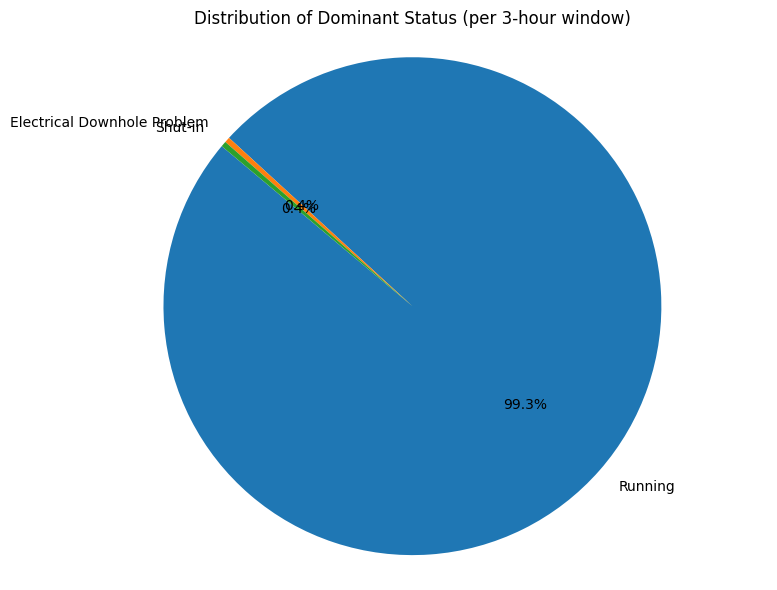

In [39]:
import matplotlib.pyplot as plt

# Hitung jumlah kemunculan setiap Dominant Status dalam hasil akhir
status_counts = result_df['Dominant Status'].value_counts()

# Buat pie chart
plt.figure(figsize=(8, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Dominant Status (per 3-hour window)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

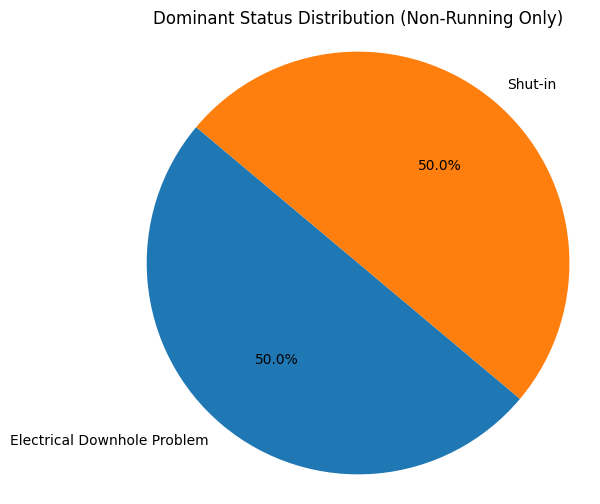

In [40]:
# 2. Pie Chart: Hanya status dominan non-"Running"
status_counts_non_running = result_df[result_df['Dominant Status'] != 'Running']['Dominant Status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts_non_running, labels=status_counts_non_running.index, autopct='%1.1f%%', startangle=140)
plt.title('Dominant Status Distribution (Non-Running Only)')
plt.axis('equal')  # Circle
plt.show()

In [41]:
filtered_df.to_csv('prediction_results_30menit_30Maret2025.csv', index=False)

In [42]:
result_3jam.to_csv('result_df_3 jam.csv', index=False, encoding="utf-8-sig")

In [43]:
prediction_results_df.to_csv('prediction_results_30menit.csv', index=False)

In [44]:
indicator.to_csv('indicator_30menit.csv', index=False, encoding="utf-8-sig")